Einer Barba Abdala 595839

Renata García Morales 612194

Título: Actividad 4: Single-Neuron Network With And WithoutPCA

Date: 06/03/2025

Materia: Inteligencia Artificial II

*Declaramos que hemos realizado esta actividad con intégridad académica.*

**Dominio de aplicación y características generales**

Este dataset pertenece al área médica, siendo que este evalúa el área de detección de evaluación de factores de riesgo asociados al cáncer cervical. Los datos fueron recolectados a partir del "Hospital Universitario de Caracas" en Venezuela e incluye una diversa cantidad de datos desde demografías, hábitos de vida y antecedentes médicos de los pacientes. El dataset contiene variables tanto enteras como booleanas, contiene datos faltantes que se manejarán durante el ejercicio y contiene un total de 36 variables y 858 pacientes.

El dataset está siendo hosteado en el sitio web UC Irvine Machine Learning Repository: https://archive.ics.uci.edu/dataset/383/cervical+cancer+risk+factors

Este dataset cuenta con una variable target de tipo bool, representando la ausencia o presencia de cáncer. Por ello, se tomará este dataset desde una perspectiva de un problema de clasificación.


**Variables predictoras**

Estas variables se pueden dividir en 5 categorías distintas.

1.- Existe un único tipo de variable que de información demográfica ya que se sabe que todas las pacientes son mujeres.

  - Edad

2.- Por otro lado se encuentran las variables relacionadas a los antecedentes tanto sexuales como reproductivos.

  - Número de parejas sexuales

  - Edad de la primera relación sexual

  - Número de embarazos

3.- Diferentes hábitos o elementos en el estilo de vida de la persona como lo es el consumo del tabaco al igual que el uso de métodos anticonceptivos.
  - Fuma

  - Años fumando

  - Paquetes por año

  - Uso de anticonceptivos hormonales

  - Años de uso de anticonceptivos hormonales

  - Uso de DIU

  - Años de uso del DIU


4.- Historial de enfermades de transmisión sexual.
  - Indicador general de ETS

  - Número de ETS

  - Número de diagnósticos de ETS

  - Tiempo desde el primer diagnóstico de ETS

  - Tiempo desde el último diagnóstico de ETS

  - ETS: Condilomatosis

  - ETS: Condilomatosis cervical

  - ETS: Condilomatosis vaginal

  - ETS: Condilomatosis vulvo-perineal

  - ETS: Sífilis

  - ETS: Enfermedad pélvica inflamatoria

  - ETS: Herpes genital

  - ETS: Molusco contagioso

  - ETS: SIDA

  - ETS: VIH

  - ETS: Hepatitis B

  - ETS: Virus del Papiloma Humano (VPH)

5.- Diagnósticos previos hechos al paciente.
  - Dx (diagnóstico general previo)

  - Dx:Cancer

  - Dx:CIN

  - Dx:HPV

  **Variable objetivo**

Se elegió la variable de "Biopsy" o biopsia en español como la variable objetivo. Esta variable indica si el resultado del estudio confirma la presencia de tejido canceroso. Esto lo hace una variable binaria donde los resultados pueden ser ya sea 0 o 1. En caso de 0, el resultado es negativo, por lo que no hay cáncer. Un 1 significaría un resultado positivo, es decir, hay presencia de cáncer o al menos una anomalía significativa.


In [348]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


1. Antes de realizar la limpieza de los datos se carga el dataset. Para facilitar la limpieza se cambian todos los signos de interrogación a valores nulos para ser maniuplados más fácilmente en pasos próximos. Después, se utiliza head() para confirmar que se leyó el documento correctamente. También se usa shape para poder observar el tamaño del dataset.

In [349]:
df = pd.read_csv("risk_factors_cervical_cancer.csv", header=0,na_values="?")
print(df.shape)
df.head()

(858, 36)


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


Se puede observar que la DataFrame ha sido generada correctamente, y se cuentan con 858 entradas, cada una con 36 variables.

2. Se utiliza df.columns para poder saber el nombre de cada una de las variables para facilitar el proceso futuro.

In [350]:
df.columns

Index(['Age', 'Number of sexual partners', 'First sexual intercourse',
       'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
       'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD',
       'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis',
       'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
       'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
       'STDs:pelvic inflammatory disease', 'STDs:genital herpes',
       'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV',
       'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis',
       'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis',
       'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller',
       'Citology', 'Biopsy'],
      dtype='object')

# **Limpieza de datos**

1. Antes de iniciar con la limpieza de datos se eliminan estas 3 variables las cuales servirían como otros casos de variables objetivo. Dado que se busca utilizar como variable objetivo Biopsy, se eliminan estas otras pruebas que podrían ocasionar fuga de datos, y empeorar el rendimiento del modelo.

In [351]:
df = df.drop(columns=[
    "Hinselmann",
    "Schiller",
    "Citology",
])

2. Se observan cuales son los datos nulos de cada una de las variables para saber como manejarlos próximamente.

In [352]:
missing =  df.isnull().sum() / len(df) * 100
missing.sort_values(ascending=False)

,0
STDs: Time since first diagnosis,91.724942
STDs: Time since last diagnosis,91.724942
IUD (years),13.636364
IUD,13.636364
Hormonal Contraceptives,12.587413
Hormonal Contraceptives (years),12.587413
STDs:HPV,12.237762
STDs (number),12.237762
STDs,12.237762
STDs:vaginal condylomatosis,12.237762


3. En las variables "STDs: Time since first diagnosis" y "STDs: Time since last diagnosis", más del 90% de los valores son nulos. Por ello, se decidió eliminar las columnas, ya que no aportan suficiente información valiosa como para justificar el mantenerlas.

In [353]:
df = df.drop(columns=["STDs: Time since first diagnosis", "STDs: Time since last diagnosis"])

4. Las demás columnas con nulos que contaran con un porcentaje nulo mayor al 5% se imputaron por medio del uso de la mediana. Esto permite utilizar estas entradas restantes, con datos que podrían ser considerados los más "normales". Usar la mediana en lugar de la media permite evitar sesgos causados por outliers.

In [354]:
cols_imputar = [
    "IUD", "IUD (years)", "Hormonal Contraceptives", "Hormonal Contraceptives (years)",
    "STDs:HPV", "STDs:AIDS", "STDs:Hepatitis B", "STDs:HIV", "STDs",
    "STDs:cervical condylomatosis", "STDs:vulvo-perineal condylomatosis", "STDs:syphilis",
    "STDs:pelvic inflammatory disease", "STDs:vaginal condylomatosis", "STDs:genital herpes",
    "STDs:molluscum contagiosum", "STDs:condylomatosis", "STDs (number)", "Num of pregnancies"
]

for col in cols_imputar:
    df[col] = df[col].fillna(df[col].median())

5. En el resto de variables que contenían menos del 5% de nulos se optó por eliminar las filas, ya que esto representa una pérdida mínima de información, mientras que también minimizamos el imputar más datos de los que ya hemos hecho en el paso pasado. Esto nos permite un buen balance entre mantener una cantidad útil de entradas y además una cantidad mínima de datos "generados".

In [355]:
cols_dropna = ["Number of sexual partners", "Smokes", "Smokes (packs/year)", "Smokes (years)", "First sexual intercourse"]
df = df.dropna(subset=cols_dropna)

6. Se corrobora que una vez se realizó la limpieza ya no quedan más nulos en el dataset.

In [356]:
missing =  df.isnull().sum() / len(df) * 100
missing.sort_values(ascending=False)

,0
Age,0.0
Number of sexual partners,0.0
First sexual intercourse,0.0
Num of pregnancies,0.0
Smokes,0.0
Smokes (years),0.0
Smokes (packs/year),0.0
Hormonal Contraceptives,0.0
Hormonal Contraceptives (years),0.0
IUD,0.0


7. Se ve la forma final para verificar que los cambios fueron hechos exitosamente y que aún se conserve un número de entradas significante.

In [357]:
print(df.shape)
df.head(30)

(814, 31)


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Biopsy
0,18,4.0,15.0,1.0,0.0,0.000000,0.00,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.000000,0.00,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.000000,37.00,1.0,3.00,0.0,...,0.0,0.0,0.0,0.0,0,1,0,1,0,0
4,46,3.0,21.0,4.0,0.0,0.000000,0.00,1.0,15.00,0.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,0
5,42,3.0,23.0,2.0,0.0,0.000000,0.00,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,0
6,51,3.0,17.0,6.0,1.0,34.000000,3.40,0.0,0.00,1.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,1
7,26,1.0,26.0,3.0,0.0,0.000000,0.00,1.0,2.00,1.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,0
8,45,1.0,20.0,5.0,0.0,0.000000,0.00,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0,1,0,1,1,0
9,44,3.0,15.0,2.0,1.0,1.266973,2.80,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,0
10,44,3.0,26.0,4.0,0.0,0.000000,0.00,1.0,2.00,0.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,0


Como se puede observar, se eliminaron solamente 44 entradas, aproximadamente un 5% de los datos originales. A cambio de esto, la DataFrame ahora está limpia sin datos nulos.

# **Análisis exploratorio de datos**

1. Describe se utiliza para poder analizar las estadísticas descriptivas de las variables numéricas permitiendo observar elementos esenciales como el promedio, mínimo, máximo, etc.

In [358]:
df.describe()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Biopsy
count,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,...,814.0,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000
mean,26.852580,2.512285,17.013514,2.265356,0.147420,1.224076,0.458960,0.685504,2.094268,0.099509,...,0.0,0.019656,0.001229,0.002457,0.085995,0.020885,0.011057,0.020885,0.028256,0.065111
std,8.582306,1.606941,2.840329,1.410156,0.354742,4.081365,2.257969,0.464600,3.636691,0.299528,...,0.0,0.138901,0.035050,0.049538,0.297551,0.143086,0.104631,0.143086,0.165804,0.246873
min,13.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,2.000000,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,25.000000,2.000000,17.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.500000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32.000000,3.000000,18.000000,3.000000,0.000000,0.000000,0.000000,1.000000,2.445550,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,84.000000,28.000000,32.000000,11.000000,1.000000,37.000000,37.000000,1.000000,30.000000,1.000000,...,0.0,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Refiriéndose a las edades, se puede observar que la edad promedio es de apróximadamente 27 años. Existen pacientes bastante jóvenes teniendo 13 años, y algunos de los pacientes mayores tienen hasta 84. La desviación es de 8.5, lo cual es moderado. Finalmente, se ve que los pacientes se concentran entre los 20 y 32 años, ya que se muestra que el 50% de los valores caen en este rango.

Otras variables nos permiten saber que solo el 14% de los pacientes fuman, y existe una gran cantidad de pacientes que usan anticonceptivos hormonales siendo estos el 68%.

La variable "Number of sexual partners" cuenta con una media de 2.51 y una mediana de 2, pero tiene valores máximos de hasta 28. Estos outliers podrían ser relevantes.

Se pueden observar númericamente las variables binarias, representadas por un min de 0 y un max de 1. Varias de estas variables cuentan con means muy cercanos al 0, lo cual indica un sesgo hacia valores de 0 más frecuentes.




2. Con esta gráfica se puede observar la distribución de la variable objetivo.

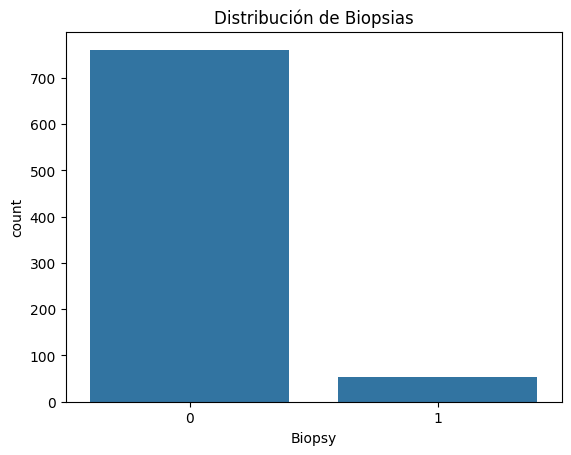

''

In [359]:
sns.countplot(x='Biopsy', data=df)
plt.title('Distribución de Biopsias')
plt.show()
,

La gráfica permite obervar que existe un problema de desbalance basante grande donde los casos negativos son bastante más numerosos que los positivos. Esto podría ser riesgoso en la creación del modelo, ya que el modelo podría adoptar este sesgo y tener una dificultad para predecir valores de 1.

3. Se realiza un histrograma el cual grafica la distribución de cada variable.

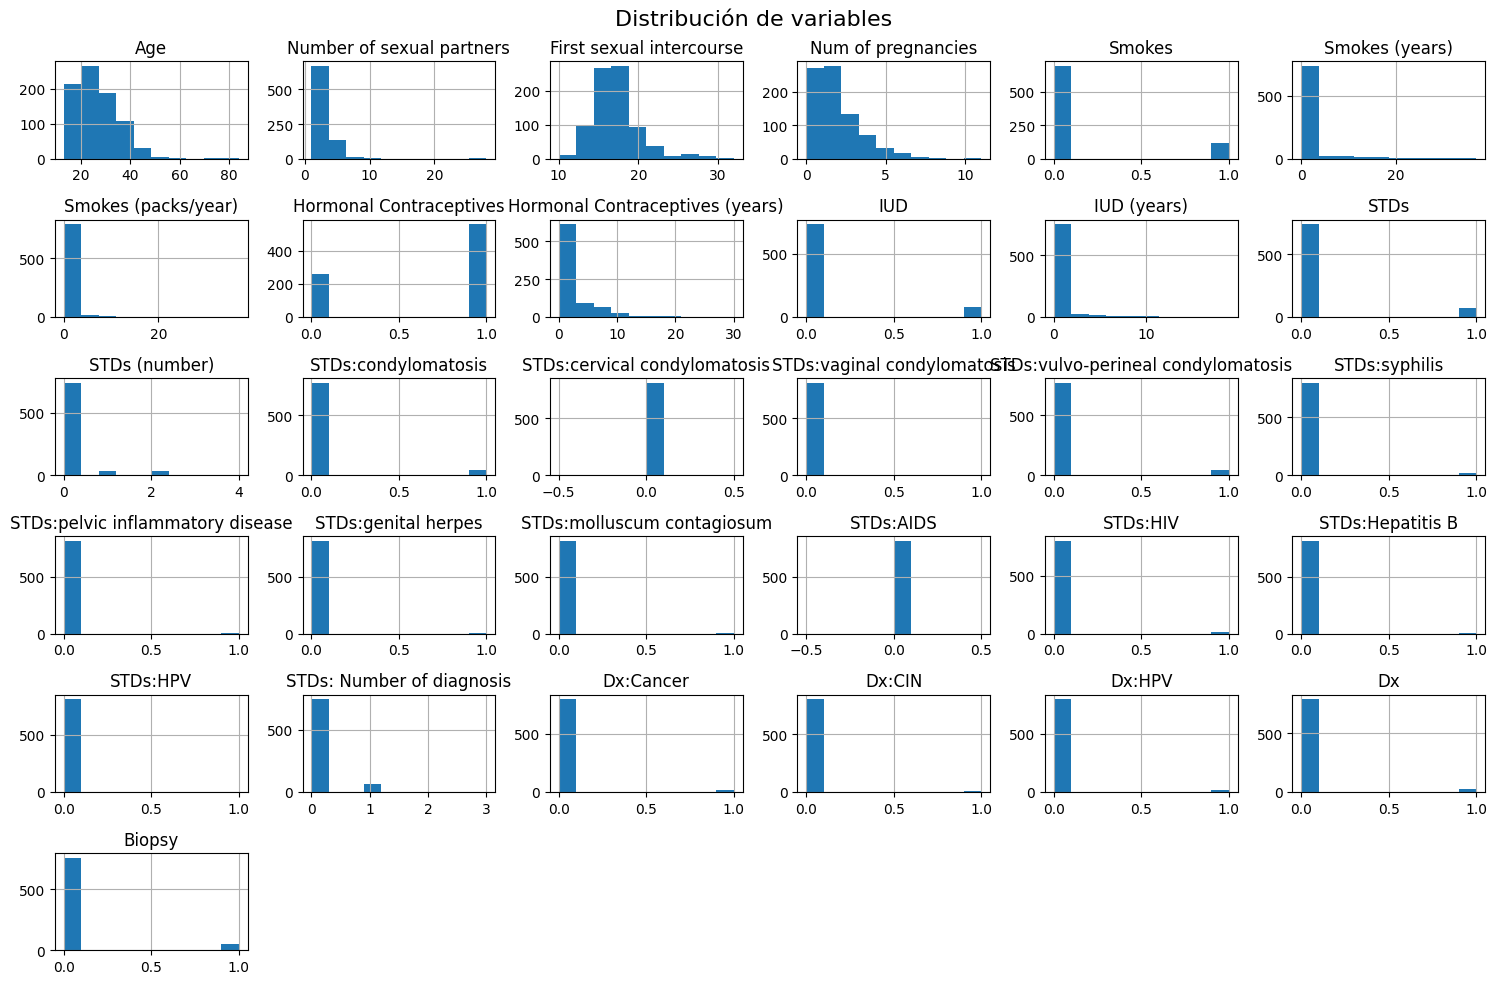

In [360]:
df.hist(figsize=(15,10))
plt.suptitle("Distribución de variables", fontsize=16)
plt.tight_layout()
plt.show()


Se puede observar que en edad, la distribución se inclina más hacia los jóvenes.

Por otro lado, en la variable de parejas sexuales, se muestra un sesgo positivo donde hay muchos valores pequeños y pocos valores realmente altos. Esto se ajusta a la observación hecha anteriormente mediante el describe.

Con respecto al tabaco, la mayoría no fuma, pero existen ciertos outliers que fuman cantidades significativas.

4. Se realizan boxplots los cuales muestran la mediana, los cuartiles y los valores que se consideran outliers esto de cada variable.

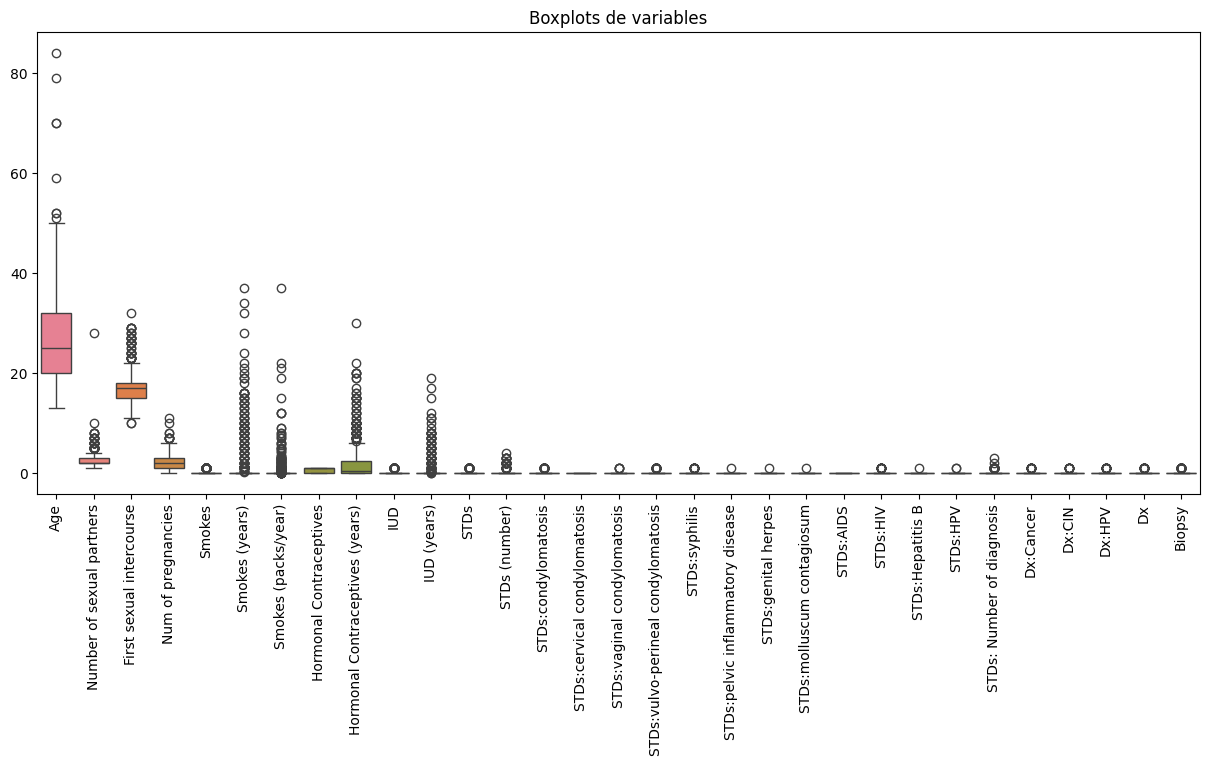

In [361]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df)
plt.xticks(rotation=90) # Rotar texto para que sea vertical.
plt.title("Boxplots de variables")
plt.show()


Esta visualización confirma los patrones notados anteriormente, donde los outliers son más comunes en las variables de número de parejas sexuales, años/cantidad que se fuma, y además en número de embarazos.

5. La matriz de correlación ayuda a calcular la correlación de Pearson entre todas las variables. Esto se visualiza por medio del heatmap.

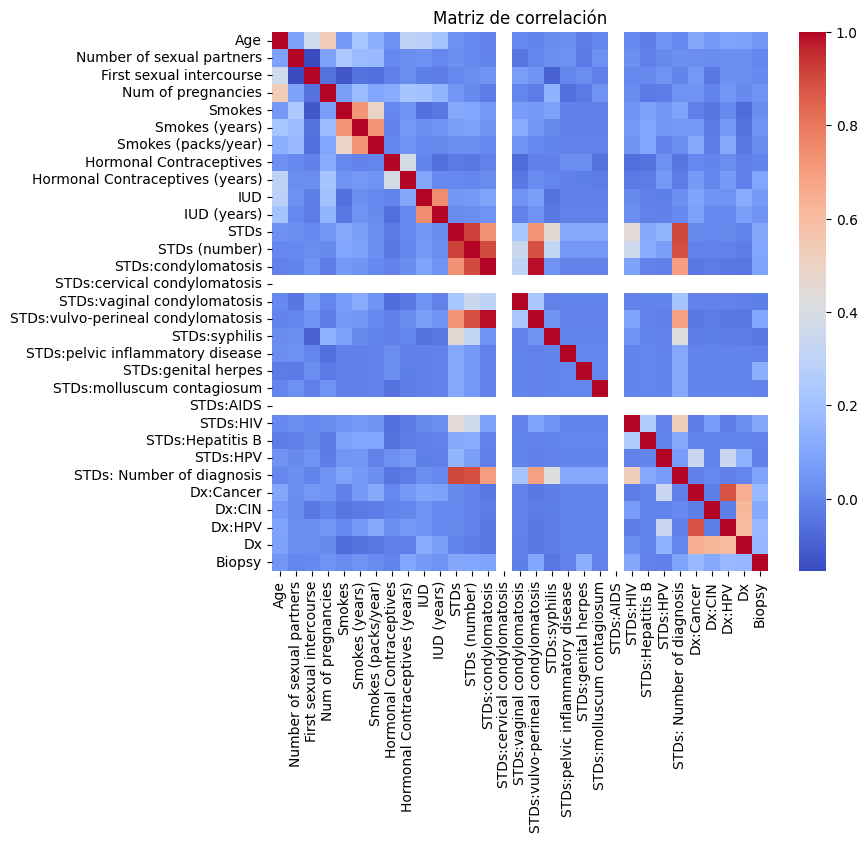

In [362]:
plt.figure(figsize=(8,7))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Matriz de correlación")
plt.show()

La matriz muestra que la mayor parte de las variables tienen correlaciones bajas, pero existen algunas relacionadas con  diagnósticos médicos que muestran correlaciones más altas entre sí. Esto tiene sentido debido a que ciertos diagnósticos se relacionan de una manera clínica.

6. Finalmente, se realizaron promedios por clase agrupados por la variable objetivo la cual es Biopsy.

In [363]:
df.groupby("Biopsy").mean()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx
Biopsy,,,,,,,,,,,,,,,,,,,,,
0,26.735874,2.512484,17.005256,2.250986,0.145861,1.182826,0.448069,0.685940,2.000321,0.094612,...,0.001314,0.0,0.015769,0.001314,0.002628,0.078844,0.014455,0.007884,0.014455,0.021025
1,28.528302,2.509434,17.132075,2.471698,0.169811,1.816358,0.615343,0.679245,3.443208,0.169811,...,0.000000,0.0,0.075472,0.000000,0.000000,0.188679,0.113208,0.056604,0.113208,0.132075


Se dividió el dataset en grupo 0 y 1 de biopsy. Se muestran diferencias pequeñas entre los resultados por ejemplo Age con 26.7 y 28.5 o Smokes con 0.145 y 0.169. Hay una diferencia más grande en Hormonal Contraceptives la cual es de 2 y 3.44. Las diferencias son en su gran mayoría pequeñas lo cual podría sugerir que las características no separan de manera clara las clases.

# **Modelo de una neurona**

1. Se inicia separando las variables predictoras de la variable objetivo. La "y" siendo Biopsy y la "X" siendo todas las demás variables restantes, consdierando que varias ya fueron eliminadas durante la limpieza.

In [364]:
y = df["Biopsy"]
X = df.drop(columns=["Biopsy"])

2. Después, se separa el 20% de los datos para la prueba y se utiliza stratify=y para mantener la proporción de clases en cada subconjunto. Esto se considera debido a que el dataset muestra desbalance.
Luego se divide el conjunto de entrenamiento.

In [365]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

print("Training size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Testing size:", X_test.shape)

Training size: (520, 30)
Validation size: (131, 30)
Testing size: (163, 30)


Los resultados muestran que 520 de los datos se usan para entrenar, otros 131 para validar en el entrenamiento y 163 para el desempeño final.

3. Después, se normalizan las variables para que tengan la media de 0 y la desviación estándar de 1. Esto permite evitar problemas futuros donde la escala de los datos numéricos erróneamente sesga el entrenamiento.

In [366]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Siguiente, se realiza el cálculo de pesos por desbalance. Esto se debe a que el dataset tiene un desbalance que debe ser manejado si queremos que el modelo aprenda los patrones de casos tanto positivos como negativos.

In [367]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights)) # Convertir lista a diccionario.

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.5349794238683128), 1: np.float64(7.647058823529412)}


Mediante este proceso, podemos compensar el desbalance de clases, castigando de manera más estricta errores en la clase minoritaria.

4. Se define el modelo de una sola neurona y una sola capa. El model.compile nos permite describir las métricas a seguir durante el entrenamiento, así como el optimizador a utilizar.

In [368]:
# Definir red neuronal, con semilla.
modelo = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)), # Definir shape de la entrada.
    tf.keras.layers.Dense(                     # Definir un modelo de 1 neurona.
        1,
        activation='sigmoid',
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42)
    )
])

# Configurar entrenamiento.
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Mostrar arquitectura.
modelo.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

Se cuenta con 31 parámetros, siendo 30 features y la neurona de salida con bias, sumando los 31.

5. Se realiza el entrenamiento de la neurona usando los datos de entrenamiento. Se tienen 100 épocas en las cuales se ajustan los 31 parámetros. Como se ve se, se utiliza el class weight para penalizar el modelo cuando este se equivoca en la clase minoritaria.

In [369]:
history = modelo.fit(
    X_train,
    y_train,
    epochs=100, # Definir hiperparámetros básicos.
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    verbose=1 # Mostrar detalles.
)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4233 - loss: 1.0849 - val_accuracy: 0.3969 - val_loss: 0.9305
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4286 - loss: 1.1800 - val_accuracy: 0.3893 - val_loss: 0.9234
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4146 - loss: 1.1135 - val_accuracy: 0.3969 - val_loss: 0.9181
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4167 - loss: 1.1465 - val_accuracy: 0.3969 - val_loss: 0.9133
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4065 - loss: 1.0688 - val_accuracy: 0.3893 - val_loss: 0.9080
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3886 - loss: 0.9679 - val_accuracy: 0.3817 - val_loss: 0.9034
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3765 - loss: 0.9759 - val_accuracy: 0.3817 - val_loss: 0.8988
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3895 - loss: 1.1755 - val_accuracy: 0.3893 - 

Los resultados demuestran que el accuracy inicia aproximadamente en 0.6 y empieza a aumentar poco a poco hasta llegar a valores cercanos a 0.8 en el entrenamiento, mientras que en validación comienza alrededor de 0.6 y sube gradualmente hasta aproximadamente 0.7. Al mismo tiempo, la pérdida disminuye, pasando de valores cercanos a 0.85 en validación a alrededor de 0.70 al final del entrenamiento. Esto indica que el modelo sí está aprendiendo durante las épocas, ya que mejora su capacidad de clasificación y reduce su error, aunque el desempeño no es completamente ideal.

6. En esta sección se grafica la evolución del accuracy durante el entrenamiento ya que se almacenan los valores registrados de cada época. Se grafican los valores de entrenamiento y los de validación.

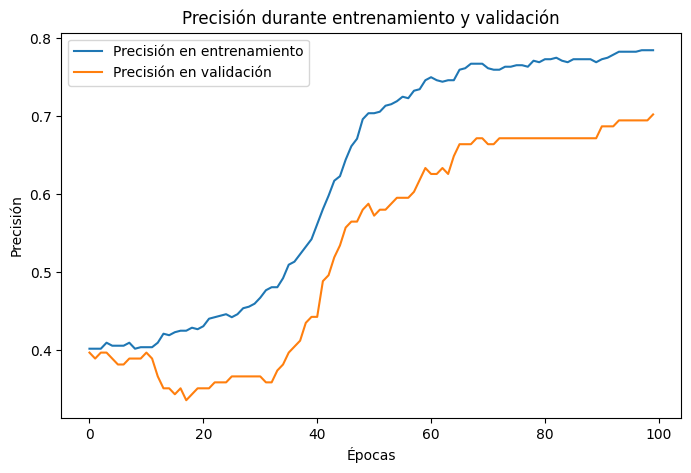

In [370]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Precisión en entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión en validación')
plt.legend()
plt.title("Precisión durante entrenamiento y validación")
plt.xlabel("Épocas")
plt.ylabel("Precisión")
plt.show()

Aquí se observa que las 2 curvas aumentan poco a poco y se mantienen cercanas. Esto da a entender que el modelo mejora poco a poco y no solo memoriza los datos. Sin emabrgo, el accuracy no llega a valores altos, y el accuracy de validación se aplana alrededor de un valor de 0.73, mientras que el valor de accuracy de training continua incrementando levemente. Esto es un indicio de overfitting, donde ambas curvas se comienzan a alejar la una de la otra.

Hasta el momento, el modelo generaliza de manera aceptable, donde la accuracy de validación si incrementa a la par que la de entrenamiento, hasta el valor mencionado anteriormente.

7. Con el próximo código se busca graficar la evolución de la pérdida del modelo durante el entrenamiento. Se usan los valores guardados en history, donde la pérdida representa el error del modelo en el conjunto de entrenamiento y val_loss el error en el conjunto de validación.

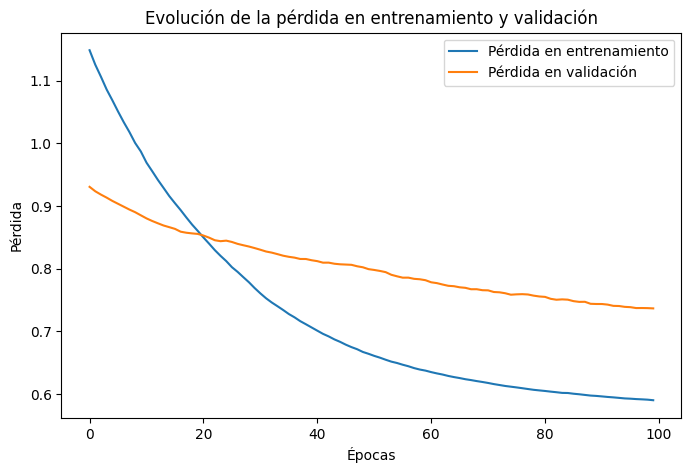

In [371]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Pérdida en entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida en validación')
plt.legend()
plt.title("Evolución de la pérdida en entrenamiento y validación")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.show()

En la gráfica se muestra que tanto la pérdida de entrenamiento como la de validación disminuyen de una manera gradual a través de las épocas, lo que nos da a entender que el modelo está aprendiendo de manera correcta. A pesar de esto, la pérdida de la validación se mantiene un poco más alta que la de entrenamiento pero de todas maneras ambas siguen una tendencia similar y no se observa que la pérdida de validación aumente. Esto sugiere que el modelo tiene un ajuste razonablemente bueno y no presenta señales claras de overfitting, aunque aún existe margen de mejora en su capacidad de generalización.

8. En esta parte se usa el modelo entrenado para predecir las clases de los datos de prueba. Primero calcula las probabilidades de cada predicción y luego las convierte en valores binarios siendo 0 o 1 usando un umbral de 0.5 para obtener la clasificación final.

In [372]:
y_pred_prob = modelo.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


9. Después se calcula la matriz de confusión comparando el y_test con el y_pred. La función de confusion_matrix genera una tabla que muestra cuántas predicciones fueron correctas o incorrectas para cada clase.

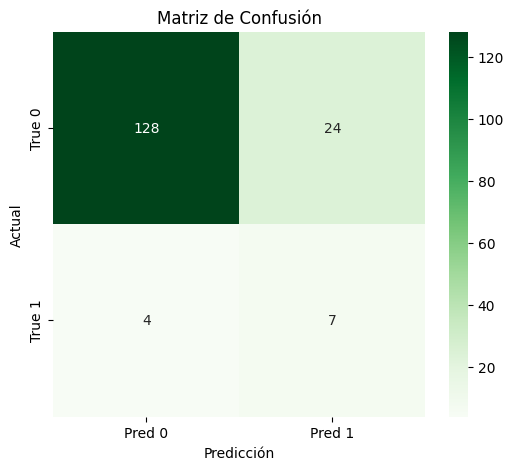

In [373]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Pred 0','Pred 1'],
    yticklabels=['True 0','True 1']
)

plt.xlabel('Predicción')
plt.ylabel('Actual')
plt.title('Matriz de Confusión')
plt.show()

Aquí se ve que el modelo predijo de manera correcta 126 casos negativos y 5 casos positivos. Sin embargo, 26 casos negativos fueron clasificados incorrectamente como positivos, y 6 casos positivos fueron clasificados como negativos. Esto muestra que el modelo funciona mejor identificando la clase negativa que la positiva lo cual tiene sentido con el desbalance analizado anteriormente.

En nuestro caso, se podría decir que el valor más importante es el Recall, algo común en el área médica. Esta métrica define la cantidad de 1s que fueron correctamente identificados. El "asustar" a un paciente con una diagnosis falsa que luego puede ser analizada a profundidad para corregirla representa menos consecuencias, en comparación a permitir que un paciente enfermo piense que está sano, y se vaya sin tratamiento.

10. Finalmente, se calculan diversas métricas de evaluación del modelo usando las predicciones las cuales son y_pred y los valores reales siendo estos y_test. Se obtienen la precisión, el recall, la especificidad y el puntaje F1, que ayudan a medir qué tan bien el modelo clasifica los datos.

In [374]:
# Calcular métricas.
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Extraer valores para matriz.
tn, fp, fn, tp = cm.ravel()
especificidad = tn / (tn + fp)

# Calcular F1 score.
f1 = f1_score(y_test, y_pred)

print("Precisión:", precision)
print("Sensibilidad (Recall):", recall)
print("Especificidad:", especificidad)
print("Puntaje F1:", f1)


Precisión: 0.22580645161290322
Sensibilidad (Recall): 0.6363636363636364
Especificidad: 0.8421052631578947
Puntaje F1: 0.3333333333333333


Los resultados muestran que la precisión es baja con un resultado de casi 0.2, lo que muestra que muchas de las predicciones positivas del modelo son incorrectas. El recall es 0.6, que significa que el modelo logra detectar cerca del 45% de los casos positivos reales. La especificidad es alta con alrededor de 0.8, lo que indica que el modelo identifica de manera correcta la mayoría de los casos negativos. Para terminar, el F1 score es bajo con alrededor de 0.3, lo que muestra un desempeño limitado del modelo para equilibrar precisión y recall.

Para nuestros propósitos, el performance del modelo es impresionante, considerando que solo se usa 1 capa y una neurona. Sin embargo, para aplicaciones médicas reales, una precisión tan baja del 0.2 sería inaceptable, incluso con un recall relativamente alto. Es claro que el modelo contiene áreas de oportunidad.

11. Al terminar se guarda el modelo entrenado en un archivo para poder usarlo después y load_model carga ese modelo guardado nuevamente para poder reutilizarlo sin tener que volver a entrenarlo.

In [375]:
modelo.save("single_neuron_antes_de_pca.keras")

In [376]:
modelo_cargado = tf.keras.models.load_model("single_neuron_antes_de_pca.keras")

Es importante el poder guardar y cargar modelos ya entrenados. Un entrenamiento es un cálculo de valores, que luego pueden usarse para calcular predicciones. Este cálculo suele llegar a ser la parte más tardada de la creación de un modelo de IA. Por ello, el tener el conocimiento de como guardar este cálculo, y cargarlo en otro momento, puede representar un enorme ahorro de tiempo.

# Implementación PCA

1. Primero, podemos utilizar una matriz de correlación para entender la relación entre nuestras variables.

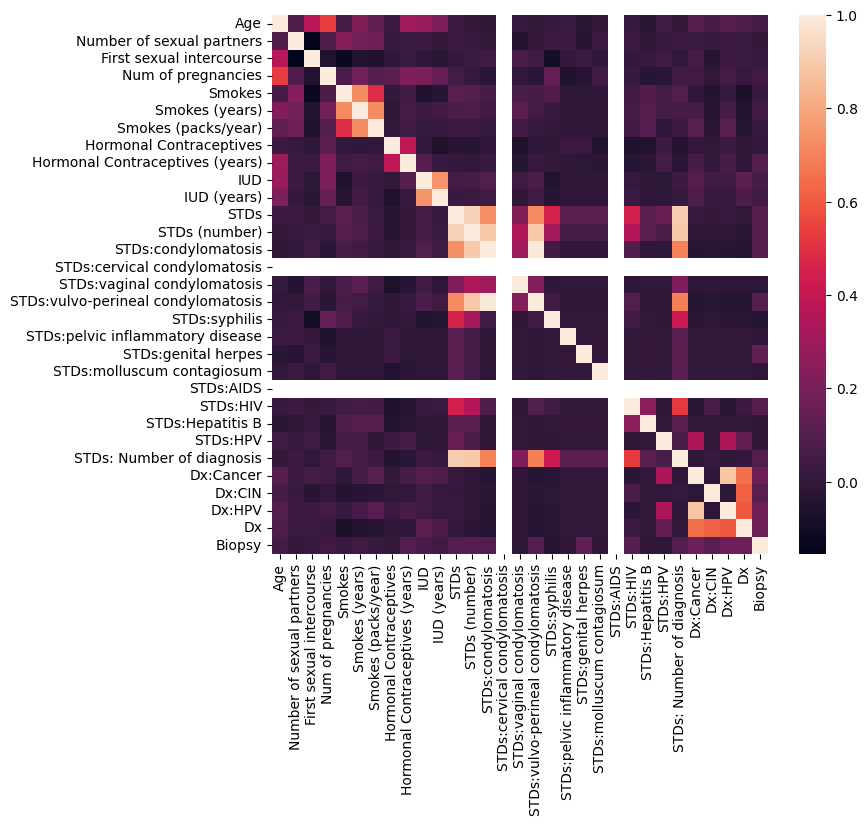

In [377]:
df_temp = df.copy()
df_temp = df_temp.corr(numeric_only=True)

plt.figure(figsize=(8,7))
sns.heatmap(df_temp, fmt=".2f")
plt.show()

Podemos observar que existen varias variabels correlacionadas, significando que estas muestran información similar. Esto era de esperarse, pues existen variables como IUD y IUD (years), que pueden ser tomadas como maneras de representar las mismas tendencias con unidades diferentes.

Esto significa que nuestro data set es un buen caso donde usar PCA, ya que este proceso tomará estas variables con información similar y podrá reducir la dimensionalidad de nuestros datos.

2. Para comenzar con el proceso de PCA, debemos estandarizar los datos, removiendo sesgos por escalas de unidades. Podemos lograr esto con la función StandardScaler. Debemos también remover la variable Biopsy para evitar fuga de datos.

In [378]:
df_x = df.drop(columns=['Biopsy'])

In [379]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_x)
df_scaled

array([[-1.03212616e+00,  9.26374747e-01, -7.09337397e-01, ...,
        -1.05736107e-01, -1.46047894e-01, -1.70520138e-01],
       [-1.38189747e+00, -9.41674082e-01, -1.06162577e+00, ...,
        -1.05736107e-01, -1.46047894e-01, -1.70520138e-01],
       [ 2.93194871e+00,  1.54905769e+00, -3.57049025e-01, ...,
        -1.05736107e-01,  6.84706893e+00, -1.70520138e-01],
       ...,
       [-2.15993095e-01, -3.18991139e-01, -4.76065367e-03, ...,
        -1.05736107e-01, -1.46047894e-01, -1.70520138e-01],
       [ 7.16730403e-01, -3.18991139e-01,  2.46125795e+00, ...,
        -1.05736107e-01, -1.46047894e-01, -1.70520138e-01],
       [ 2.50368654e-01, -3.18991139e-01,  1.05210446e+00, ...,
        -1.05736107e-01, -1.46047894e-01, -1.70520138e-01]])

3. El siguiente paso es el cómputo de la matriz de covarianza.

In [380]:
import numpy as np

cov_matrix = np.cov(df_scaled, rowvar=False)
print(cov_matrix)


[[ 1.00123001e+00  8.75539061e-02  3.68833648e-01  5.35540772e-01
   5.28652364e-02  2.21547427e-01  1.31869009e-01  3.31283108e-02
   2.99483791e-01  2.83104283e-01  2.15217683e-01  3.02744264e-02
   5.59361493e-03 -8.30341628e-03  0.00000000e+00  9.41253812e-03
  -5.87243528e-03  2.05649255e-02  2.51677513e-02 -2.80546996e-02
   6.03543197e-04  0.00000000e+00  1.07014234e-02 -2.80546996e-02
   4.14078886e-02  6.42336539e-03  1.03802854e-01  6.21630731e-02
   9.47770542e-02  8.60181742e-02]
 [ 8.75539061e-02  1.00123001e+00 -1.55048264e-01  8.49697174e-02
   2.40938283e-01  1.77583562e-01  1.73493885e-01  1.01363834e-02
   2.48634856e-02  3.19953630e-02  4.91079734e-03  2.80141315e-02
   1.08202192e-02 -1.78645639e-03  0.00000000e+00 -4.43497445e-02
  -1.29067234e-05  2.83398583e-02  3.25293432e-02 -3.30665743e-02
   3.25293432e-02  0.00000000e+00  2.65027991e-02 -1.12012685e-02
   1.50905099e-02  2.86925254e-02  2.29837764e-02  1.75015630e-02
   2.83398583e-02  2.41160694e-02]
 [ 3.6

4. Después de esto, siguen los eigenvalores y eigenvectores.

In [381]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Eigenvalues:\n", eigenvalues)
print("Eigenvectors (columns correspond to eigenvalues):\n", eigenvectors)

Eigenvalues:
 [ 4.72977368e+00  2.83757174e+00  2.45569212e+00  2.04207761e+00
  1.56169383e+00  1.45928413e+00  1.30294226e+00  1.28687883e+00
  1.15179615e+00  1.03458136e+00  1.02302484e+00  9.98147619e-01
  9.00601517e-01  8.42103993e-01  8.27483991e-01  7.43963945e-01
  7.24273248e-01  5.88485003e-01  4.79929408e-01  2.74860202e-01
  2.40838413e-01  1.74284229e-01  1.31599248e-01  8.91098674e-02
  7.43376238e-02  5.04951732e-02  8.61032352e-03  7.51245094e-17
 -1.55833146e-16 -1.55340090e-15]
Eigenvectors (columns correspond to eigenvalues):
 [[-2.03202530e-02  2.78087938e-01 -1.24184797e-01  3.80007529e-01
  -1.85475595e-01  7.82170961e-02 -2.88467332e-01  1.78329260e-01
   2.15919068e-01 -6.07994992e-02 -4.84432571e-02 -5.84052965e-02
   1.57105809e-01  1.19111870e-02  2.93519796e-02  4.17946087e-02
   1.18581536e-01 -4.46239145e-02  1.14295647e-02  6.81911659e-01
  -1.21553385e-01  1.53607536e-01  6.04176944e-02 -2.89601017e-03
  -1.06892943e-02 -7.22786876e-03  1.43648819e-03 

5. Una vez contamos con estos eigenvectores y eigenvalores, podemos ordenarlos de mayor a menor, y encontrar cuantos componentes necesitamos para capturar al menos un 95% de la varianza total.

In [382]:
explained_var_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_var = np.cumsum(explained_var_ratio)
print(cumulative_var)

[0.16871297 0.26993032 0.35752586 0.43036761 0.48607387 0.53812714
 0.58460362 0.63050712 0.67159216 0.7084961  0.74498782 0.78059215
 0.81271698 0.84275517 0.87227187 0.89880937 0.92464449 0.94563599
 0.96275527 0.97255965 0.98115045 0.98736724 0.99206144 0.99524003
 0.99789168 0.99969287 1.         1.         1.         1.        ]


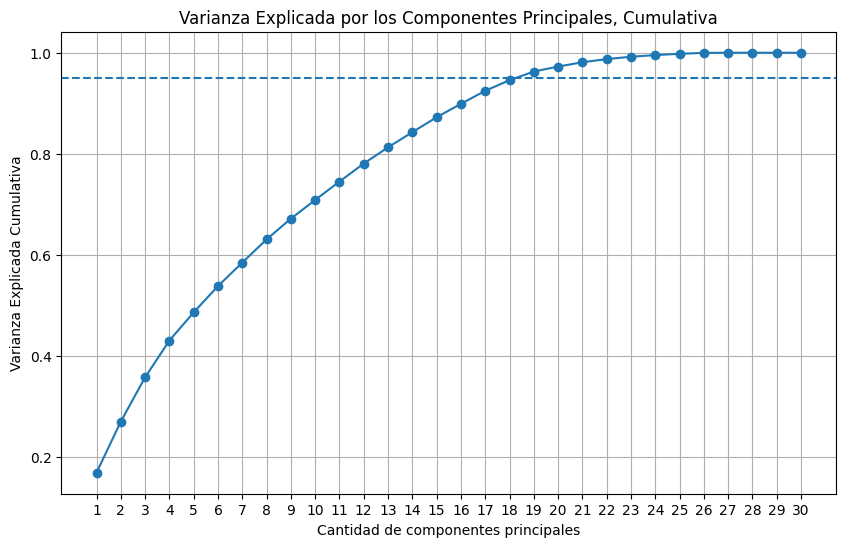

In [383]:
plt.figure(figsize=(10,6))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o')
plt.axhline(y=0.95, linestyle='--')
plt.grid(True)

plt.xlabel("Cantidad de componentes principales")
plt.ylabel("Varianza Explicada Cumulativa")
plt.title("Varianza Explicada por los Componentes Principales, Cumulativa")

plt.xticks(range(1, len(cumulative_var)+1)) # Línea mostrando el límite de 95%.

plt.show()

Como podemos observar, requeriremos 19 componentes para capturar el valor de varianza mínimo de 95%.

In [384]:
n_components = 19
transformation_matrix = eigenvectors[:, :n_components]
transformation_matrix

array([[-2.03202530e-02,  2.78087938e-01, -1.24184797e-01,
         3.80007529e-01, -1.85475595e-01,  7.82170961e-02,
        -2.88467332e-01,  1.78329260e-01,  2.15919068e-01,
        -6.07994992e-02, -4.84432571e-02, -5.84052965e-02,
         1.57105809e-01,  1.19111870e-02,  2.93519796e-02,
         4.17946087e-02,  1.18581536e-01, -4.46239145e-02,
         1.14295647e-02],
       [-1.99977630e-02,  1.16113080e-01, -1.89152636e-01,
        -6.13581492e-02,  6.91182442e-02,  1.16182114e-01,
         2.78053521e-01, -6.09290173e-02,  1.11275738e-01,
        -1.93254526e-01, -2.72770589e-01,  6.84113853e-02,
         6.12217837e-01,  8.17168579e-02,  4.32513344e-01,
         1.70874163e-01, -3.14864341e-01,  3.30269813e-02,
         9.61673671e-02],
       [-8.12764081e-03,  3.53205064e-02,  8.96365000e-02,
         1.35545090e-01, -2.05250921e-01, -1.66692766e-01,
        -5.85702455e-01,  2.84816294e-01,  8.61204124e-02,
        -1.11988280e-01,  9.63845686e-03, -4.36532811e-02,
    

6. Con esto, tenemos nuestra matriz de transformación, y podemos derivar nuestros componentes principales de la siguiente manera:

In [385]:
PC_19 = df_scaled.dot(transformation_matrix)
PC_19

array([[ 0.72231531, -1.04415446,  0.32438342, ...,  0.01578852,
        -0.76538767,  0.33542765],
       [ 0.76964283, -1.37076955,  0.68958816, ...,  0.70629627,
        -0.85848823,  0.17536705],
       [-0.88616408, 13.82890882, -9.57225729, ..., -0.76109389,
         0.38243822,  8.56533249],
       ...,
       [ 0.7874139 , -0.96854682,  0.56179252, ..., -0.71645746,
         0.35291918,  0.20583752],
       [ 0.71521733, -0.32305022,  0.42840374, ..., -0.93665708,
         1.03452764, -0.0202341 ],
       [ 0.75241697, -0.63513402,  0.47019873, ..., -0.76396141,
         0.58820258,  0.10543076]])

In [386]:
# Crear dataframe con los 19 componentes seleccionados.
df_pcs = pd.DataFrame(PC_19, columns=[f'PC{i}' for i in range(1, 20)])

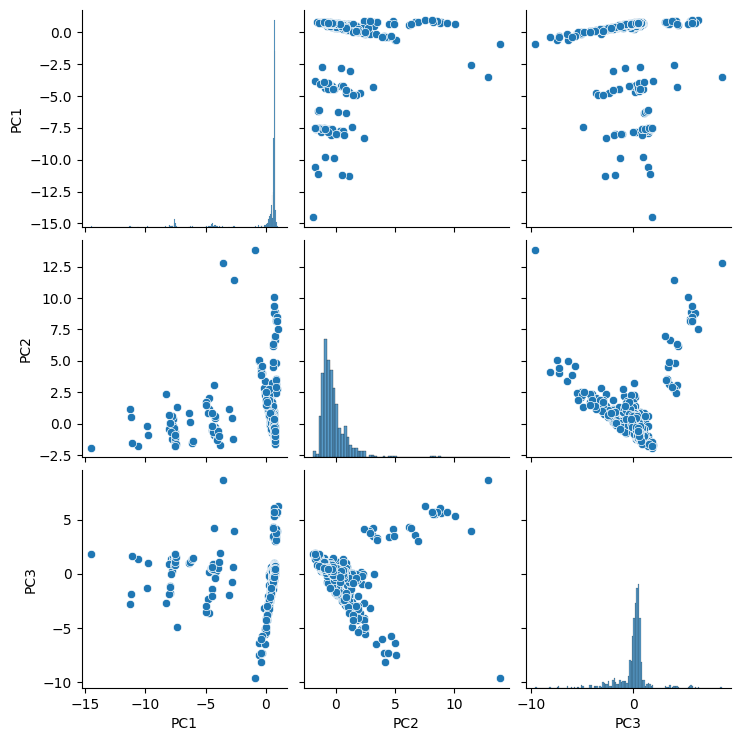

In [387]:
# Nueva DataFrame con los 3 primeros componentes, para visualizarlos.
pcs_subset = df_pcs[['PC1', 'PC2', 'PC3']]

# Gráficos comparando componentes en pares.
sns.pairplot(pcs_subset)
plt.show()

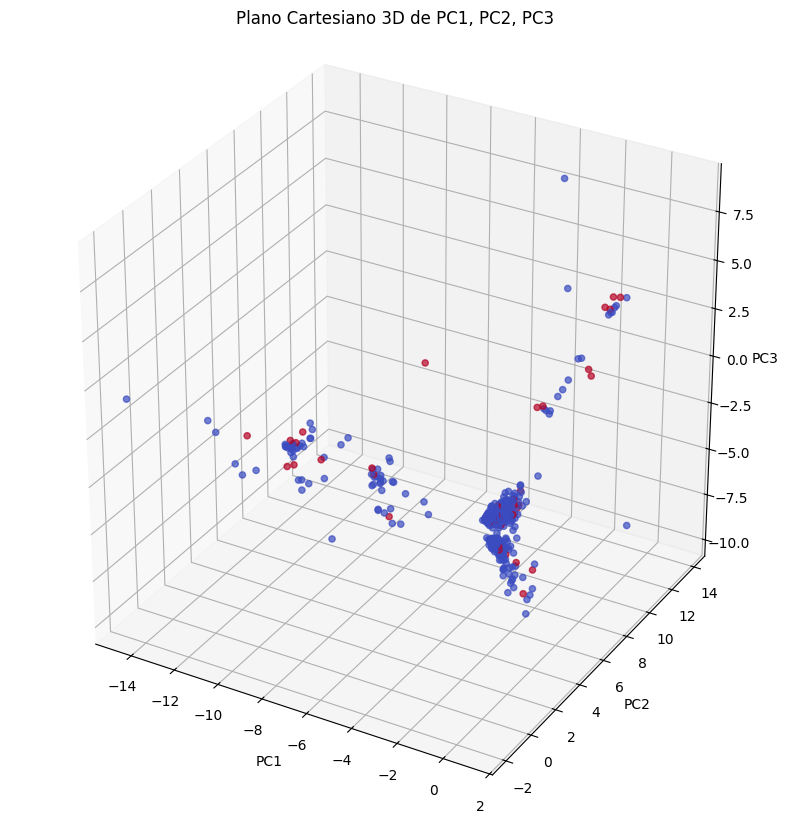

In [388]:
from mpl_toolkits.mplot3d import Axes3D

# Crear figura 3d.
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')

# Definir escalas iguales para todos los lados.
ax.set_box_aspect([1, 1, 1])

# Visualizar datos con color basado en clase en Biopsy.
sc = ax.scatter(df_pcs['PC1'], df_pcs['PC2'], df_pcs['PC3'],
                c=df['Biopsy'], cmap='coolwarm', alpha=0.7)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Plano Cartesiano 3D de PC1, PC2, PC3')


plt.show()

Podemos obserar una representación 3D de los 3 primeros componentes principales que hemos generado. Podemos observar como se generan agrupaciones de datos específicas, separadas entre si dependiendo de su valor en las 3 escalas, PC 1, 2, y 3.

La dimensionalidad de nuestros datos terminó siendo reducida desde 36 a tan solo 19, una reducción significativa. Como se mencionó en el análisis de la matriz de correlación, existía una cantidad significativa de redundancia en los datos, con varias variables representando datos muy similares. Esto es evidenciado debido al hecho de que para capturar casi toda la varianza en el dataset, se requiere una cantidad mínima de componentes, 19, en comparación a las 36 variables iniciales.

# **Modelo de una neurona: PCA**

1. Se inicia separando las variables predictoras de la variable objetivo.
La variable "y" sigue siendo la columna Biopsy original, y la X es nuestros componentes.

In [389]:
y2 = df["Biopsy"]
X2 = df_pcs

2. Después de esto se separa el 20% de los datos para la prueba y se utiliza stratify=y para mantener la proporción de clases en cada subconjunto, porque el dataset muestra desbalance. Luego se divide el conjunto de entrenamiento.

In [390]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

print("Training size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Testing size:", X_test.shape)

Training size: (520, 19)
Validation size: (131, 19)
Testing size: (163, 19)


3. No es necesario aplicar StandardScaler de nuevo, ya que los componentes principales ya vienen en un formato estadarizado. El siguiente paso es realizar el cálculo de pesos por desbalance.

In [391]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Transformar lista a diccionario.
class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.5349794238683128), 1: np.float64(7.647058823529412)}


Como se hizo anteriormente, una vez más se muestra el desbalance de las clases.

4. Se define el modelo de una sola neurona y una sola capa.

In [392]:
# Definir red neuronal, con semilla.
modelo = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)), # Definir shape de la entrada.
    tf.keras.layers.Dense(                     # Definir un modelo de 1 neurona.
        1,
        activation='sigmoid',
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42)
    )
])

# Configurar entrenamiento.
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Mostrar arquitectura.
modelo.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 1)              │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20 (80.00 B)

 Trainable params: 20 (80.00 B)

 Non-trainable params: 0 (0.00 B)

Nuestro modelo cuenta con 20 parámetros. Esto se debe a que se tienen 19 features (componentes principales), y la neurona de output con 1 bias. Esto suma a 20.

5. Se realiza el entrenamiento de la nuerona usando los datos de entrenamiento. Se tienen 100 épocas en las cuales se ajustan los 20 parámetros. Se usa el class weight para penalizar el modelo cuando este se equivoca en la clase positiva, siendo que es la minoría.

In [393]:
history2 = modelo.fit(
    X_train,
    y_train,
    epochs=100, # Definir hiperparámetros básicos.
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    verbose=1, # Mostrar detalle.
)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4986 - loss: 0.8861 - val_accuracy: 0.5191 - val_loss: 0.7625
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4848 - loss: 0.9159 - val_accuracy: 0.5420 - val_loss: 0.7606
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4843 - loss: 0.7914 - val_accuracy: 0.5496 - val_loss: 0.7603
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5405 - loss: 0.6747 - val_accuracy: 0.5573 - val_loss: 0.7587
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5197 - loss: 0.8601 - val_accuracy: 0.5725 - val_loss: 0.7574
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4979 - loss: 0.7080 - val_accuracy: 0.5649 - val_loss: 0.7554
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4875 - loss: 0.8007 - val_accuracy: 0.5649 - val_loss: 0.7549
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5164 - loss: 0.9212 - val_accuracy: 0.5573 - 

Los resultados demuestran que el accuracy inicia aproximadamente en valores de 0.7 y empieza a aumentar poco a poco hasta llegar a valores cercanos a 0.8 en el entrenamiento, mientras que en validación comienza alrededor de 0.7 y sube gradualmente hasta aproximadamente 0.74.
Se puede decir que al usar PCA, se comienza con una accuracy más alta, a cambio de no mejorar tanto a través del entrenamiento en comparación.

El modelo sí está aprendiendo durante las épocas, ya que mejora su capacidad de clasificación y reduce su error.

6.  Se grafican los valores de entrenamiento y los de validación.

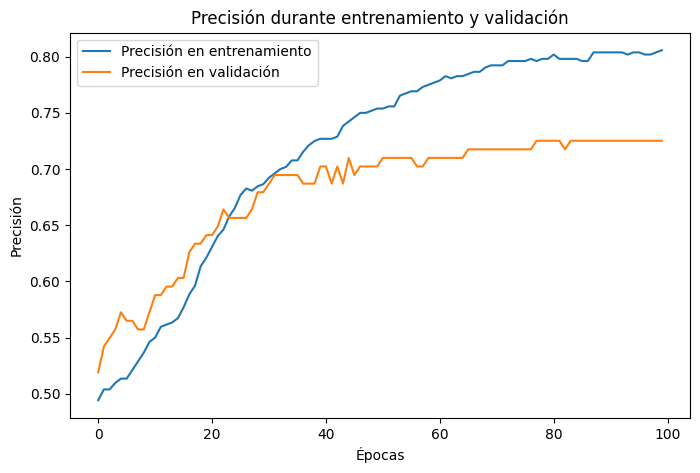

In [394]:
plt.figure(figsize=(8,5))
plt.plot(history2.history['accuracy'], label='Precisión en entrenamiento')
plt.plot(history2.history['val_accuracy'], label='Precisión en validación')
plt.legend()
plt.title("Precisión durante entrenamiento y validación")
plt.xlabel("Épocas")
plt.ylabel("Precisión")
plt.show()

Podemos observar leves diferencias en comparación al primer modelo. La precisión de entrenamiento comienza con una pendiente más pronunciada, mostrando que a pesar de que se empeiza en un valor base más bajo, el aprendizaje del modelo es más veloz.

Ambas curvas aumentan poco y se mantienen relativamente cercanas, mostrando que se está mejorando el desempeño de manera generalizada. Sin embargo, alrededor de la época 38. Esto es posiblemente un problema de overfitting, donde se deja de generalizar bien, o un problema donde el modelo no es lo suficientemente complejo como para aprender los patrones en los datos apropiadamente, siendo que los datos ahora son componentes principales.


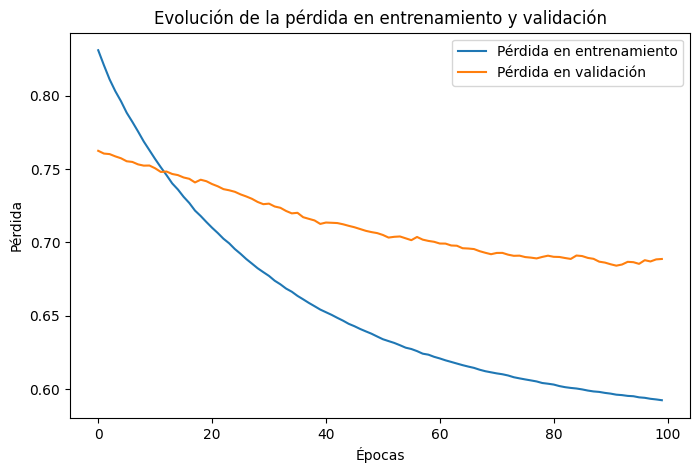

In [395]:
plt.figure(figsize=(8,5))
plt.plot(history2.history['loss'], label='Pérdida en entrenamiento')
plt.plot(history2.history['val_loss'], label='Pérdida en validación')
plt.legend()
plt.title("Evolución de la pérdida en entrenamiento y validación")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.show()

Podemos observar que, al usar PCA, el aprendizaje del modelo es mucho más veloz, alcanzando precisiones de validación a un nivel muy similar que el primer modelo, en la mitad de las épocas. Sin embargo, la mejoría de la precisión de validación, tanto del primer modelo como el segundo, deja de subir en un momento similar.

Es decir, ambos modelos tienen desempeño bueno, pero se podría decir que la mayor contirbución que dio PCA al segundo modelo fue simplificar el entrenamiento a través de la reducción de dimensionalidad. Debido a esto, el modelo pudo alcanzar las mismas altas precisiones que el primer modelo, en mucho menos tiempo.

Ya que estos recursos de tiempo se han "liberado", se podrían usar diferentes técnicas como otpimizaciones de parámetros para terminar con un modelo más preciso que utiliza una cantidad de recursos temporales y computacionales similares. Este es un gran beneficio por parte del uso de PCA. Sin embargo, para los propósitos de este ejercicio, podemos conformarnos con la mejoría del proceso ya presente.

In [396]:
y_pred_prob = modelo.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


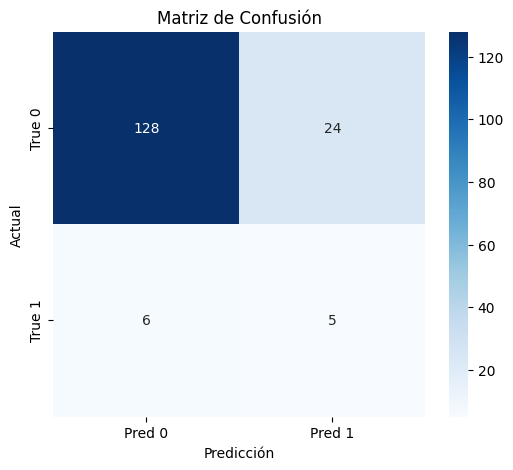

In [397]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred 0','Pred 1'],
    yticklabels=['True 0','True 1']
)

plt.xlabel('Predicción')
plt.ylabel('Actual')
plt.title('Matriz de Confusión')
plt.show()

La matriz nos muestra que los mayores problemas de precisión ocurren al momento donde la respuesta correcta sería un 0, pero el modelo predice un 1. Esto podría interpretarse como un enfoque en minimizar falsos negativos, como se mencionó anteriormente. De nuevo, representa una menor pérdida el "asustar" a un paciente con una diagnosis falsa que luego puede ser analizada a profundidad para corregirla, en lugar que a permitir que un paciente enfermo piense que está sano.

In [398]:
# Calcular métricas.
precision2 = precision_score(y_test, y_pred)
recall2 = recall_score(y_test, y_pred)

# Extraer valores para matriz.
tn, fp, fn, tp = cm.ravel()
especificidad2 = tn / (tn + fp)

# Calcular F1 score.
f1_2 = f1_score(y_test, y_pred)

print("Precisión:", precision2)
print("Sensibilidad (Recall):", recall2)
print("Especificidad:", especificidad2)
print("Puntaje F1:", f1_2)


Precisión: 0.1724137931034483
Sensibilidad (Recall): 0.45454545454545453
Especificidad: 0.8421052631578947
Puntaje F1: 0.25


In [399]:
modelo.save("single_neuron_antes_de_pca.keras")

In [400]:
modelo_cargado = tf.keras.models.load_model("single_neuron_antes_de_pca.keras")

# **Comparación**

In [401]:
# Definir tabla y columnas.
tabla_metricas = pd.DataFrame({
    "Modelo 1": [precision, recall, especificidad, f1],
    "Modelo PCA": [precision2, recall2, especificidad2, f1_2]
},
# Definir nombres de filas.
index=[
    "Precisión",
    "Sensibilidad (Recall)",
    "Especificidad",
    "Puntaje F1"
])

print(tabla_metricas)

                       Modelo 1  Modelo PCA
Precisión              0.225806    0.172414
Sensibilidad (Recall)  0.636364    0.454545
Especificidad          0.842105    0.842105
Puntaje F1             0.333333    0.250000


Podemos observar que el modelo de PCA no solo alcanza buenas métricas en menor tiempo, si no que además cuenta con mejores métricas en todos los aspectos: mejor precisión, recall, especificidad, y puntaje F1.

Todas estas mejorías se lograron con un comportamiento de aprendizaje mucho más veloz, y la estabilidad de entrenamiento se mantuvo a un nivel similar, sin empeoro evidente.

La pérdida de entrenamiento se amntiene similarmente "suave" en ambos casos, sin saltos fuertes.
Para ambos modelos, la pérdida de validación se aplana en valores similares. es decir, no se muestra empeoro considerable en el entrenamiento en cuanto a los resultados en validación, aunque existen áreas de oportunidad para lograr que el modelo generalize mejor, con o sin PCA.

Debido a estas métricas, se puede concluir que PCA fue extremadamente beneficioso, mejorando la manera en que el aprendizaje es realizado, obteniendo mejores métricas en todas las áreas.
La reducción de la dimensionalidad gracias a PCA llevó a un mejor modelo, tomando menos épocas. No hubo un trade-off entre la dimensionalidad y la performance. Al contrario, la simplificación del entrenamiento permitió llegar a mejor desempeño en las mismas 100 épocas. El único trade-off debatible del uso de PCA en este caso, sería la pérdida de interpretabilidad que sucede al usar componentes principales.

En general, si esta interpretabilidad no fuese una preocupación mayor, sería mejor desplegar el modelo PCA, al ser más rápido y además más preciso.

# **Conclusiones**

Einer:

Esta actividad fue una demostración excelente de los beneficios posibles de PCA, tanto en el área de simplificación del proceso de entrenamiento como en sus posibles beneficios. Fue interesante hacer uso de una sola neurona para la predicción de algo tan complejo como lo sería una diagnósis médica, aunque por supuesto no se tiene una precisión perfecta.
Existen varias limitaciones del estudio, por supuesto, pues el enfoque se hizo en el uso de single-neuron networks y PCA, no específicamente en la optimización perfecta de los modelos. Por ello, la precisión es un área de oportunidad. Sin embargo, con la aplicación actual de esta tarea, se puede observar excelentemente el efecto de PCA y el funcionamiento de las single-neuron networks, por lo cual me parece un desarrollo satisfactorio para el aprendizaje planteado para esta actividad.

Pasos siguientes para mejorar esta precisión incluirían data engineering con o sin PCA, optimización de hiperparámetros, y si buscamos alejarnos de las single-neuron networks, podríamos epxlorar diferentes configuraciones de la network que quizás puedan captar los patrones en los datos con más eficacia.

Github: https://github.com/einerbarba-u/04-single-neuron.git



Renata:

Se puede concluir que esta actividad nos ha permitido comprender como un modelo de una sola nuerona funciona y como se puede aplicar a un problema de clasificacación siendo en este caso dentro de un contexto médico. A través de la actividad se ha aprendido la importancia de seguir un proceso de paso a paso empezando por el preprocesamiento de los datos, continuando con la limpieza, la imputación de valores faltantes y la creación del modelo. El uso de un modelo de una sola neurona demostró que sí existen varias limitaciones debido que en este caso los patrones probablemente eran muy complejos para poder representar las relaciones entre las variables por lo cual le favorecería un modelo de más de una sola neurona. A pesar de esto, se demuestra que el modelo funciona solamente que no de la manera ideal. Por otro lado, al aplicar PCA en este caso se redujo la dimensionalidad logrando un resultado bastante favorable ya que mostró resultados muy similares pero con una cantidad menor de dimensiones.

En el futuro se podría buscar intentar otro tipo de técnicas para mejorar el mode. Por ejemplo, uno de los problemas fue el desbalance entre las clases entonces se podrían usar otras técnicas para mitigar el efecto lo más posible. También se podrían intentar ajustar los hiperparámetros o usar arquitecturas de redes neuronales que sean más profundas que quizás sean más favorables para este dataset.


Github: https://github.com/RenataGM/Single-NeuronNetworkWithAndWithoutPCA.git



# **Referencias**

Arunachalam, B. (2023, septiembre 21). Binary classification with TensorFlow tutorial. freeCodeCamp. https://www.freecodecamp.org/news/binary-classification-made-simple-with-tensorflow/


García Morales, R., & Villareal Alanís, E. M. (2025, noviembre 7). Intro Redes Neuronales [Notas de clase]. Google Colab. https://colab.research.google.com/drive/1suGLRI9sKRz6pfuJaP8RzmlDWgce1RB7?authuser=1

GeeksforGeeks. (2025, agosto 11). Single Layer Perceptron in TensorFlow. GeeksforGeeks. https://www.geeksforgeeks.org/python/single-layer-perceptron-in-tensorflow/
